# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment)

## Objective
To implement and compare the performance of:
- Model A: Single-Layer Perceptron Learning Algorithm (PLA)
- Model B: Multilayer Perceptron (MLP) with hyperparameter tuning




In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neural_network import MLPClassifier
from itertools import cycle
import warnings
warnings.filterwarnings('ignore')


import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "english.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dhruvildave/english-handwritten-characters-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)




In [2]:
import os
import sys
import pandas as pd
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from Exp1.Exp1 import perform_eda


Perform EDA imported


## 1. Preprocessing Dataset




In [3]:
# Load dataset
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import kagglehub

def load_and_preprocess_data():
    print("Downloading/Locating dataset via kagglehub...")
    # This automatically downloads the dataset and returns the root path
    dataset_path = kagglehub.dataset_download("dhruvildave/english-handwritten-characters-dataset")
    csv_path = os.path.join(dataset_path, "english.csv")
    
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"english.csv not found at {csv_path}")
        
    df = pd.read_csv(csv_path)
    
    X_list = []
    y_list = []
    
    print(f"Loading and preprocessing {len(df)} images. This may take a minute...")
    
    # Load and preprocess images
    for index, row in df.iterrows():
        img_path = os.path.join(dataset_path, row['image'])
        if not os.path.exists(img_path):
            continue
            
        try:
            # Read image, convert to grayscale, and resize to 32x32 for performance
            with Image.open(img_path) as img:
                img_gray = img.convert('L')
                img_resized = img_gray.resize((32, 32))
                
                # Flatten the image for MLP/PLA (1D array of 1024 features)
                img_array = np.array(img_resized).flatten()
                
                X_list.append(img_array)
                y_list.append(row['label'])
        except Exception as e:
            continue
            
    X = np.array(X_list)
    y = np.array(y_list)
    
    # Normalize pixel values
    print("Scaling features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Execute the loading function
X_train, X_test, y_train, y_test = load_and_preprocess_data()
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Downloading/Locating dataset via kagglehub...
Loading and preprocessing 3410 images. This may take a minute...
Scaling features...
Training set: (2728, 1024), Test set: (682, 1024)


In [4]:
df_eda = pd.DataFrame(X_train)
df_eda['target'] = y_train
# perform_eda(df_eda)


## 2. Implement PLA from scratch




In [5]:
class PerceptronFromScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.classes = None
        
    def _step_activation(self, x):
        return np.where(x >= 0, 1, 0)
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        
        # PLA is naturally binary. For multi-class, we use One-vs-All.
        # We'll create one perceptron per class.
        self.weights = np.zeros((len(self.classes), n_features))
        self.bias = np.zeros(len(self.classes))
        
        for idx, c in enumerate(self.classes):
            y_binary = np.where(y == c, 1, 0)
            
            for _ in range(self.epochs):
                linear_output = np.dot(X, self.weights[idx]) + self.bias[idx]
                y_predicted = self._step_activation(linear_output)
                
                # Update rule
                update = self.learning_rate * (y_binary - y_predicted)
                self.weights[idx] += np.dot(update, X)
                self.bias[idx] += np.sum(update)
                
    def predict(self, X):
        linear_output = np.dot(X, self.weights.T) + self.bias
        return self.classes[np.argmax(linear_output, axis=1)]

# Train PLA
pla = PerceptronFromScratch(learning_rate=0.01, epochs=100)
pla.fit(X_train, y_train)
y_pred_pla = pla.predict(X_test)



## 3 & 4. Implement MLP and Hyperparameter Tuning




In [6]:
# Define MLP and hyperparameter search space
# NOTE: the original full GridSearchCV over 32 combos x cv=3 = 96 full MLP
# trainings (each up to max_iter=100, no early stopping) was too slow and had
# to be killed with a KeyboardInterrupt. Fixed below by:
#   1. Using RandomizedSearchCV (a fixed, small n_iter budget) instead of an
#      exhaustive GridSearchCV, so runtime is bounded regardless of grid size.
#   2. Enabling early_stopping=True with a validation fraction, so an MLP
#      config that has converged (or isn't improving) stops well before
#      max_iter, instead of always running the full 100 iterations.
#   3. Reducing cv from 3 to 2 folds, which roughly halves total fit count.
#   4. Printing elapsed time and best params immediately, and also saving
#      best_params_ to a small JSON file so the result survives even if the
#      notebook's output gets cleared again.
import time
import json as _json
from sklearn.model_selection import RandomizedSearchCV

mlp = MLPClassifier(max_iter=100, early_stopping=True, n_iter_no_change=5,
                     validation_fraction=0.1, random_state=42)

param_grid = {
    'hidden_layer_sizes': [(64,), (128, 64)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [32, 128]
}

# Perform Randomized Search (bounded runtime) instead of exhaustive Grid Search
print("Starting Hyperparameter Tuning...")
start = time.time()
clf = RandomizedSearchCV(
    mlp, param_grid, n_iter=10, cv=2, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=2
)
clf.fit(X_train, y_train)
elapsed = time.time() - start

best_mlp = clf.best_estimator_
y_pred_mlp = best_mlp.predict(X_test)

print(f"Hyperparameter tuning finished in {elapsed:.1f}s")
print(f"Best MLP Parameters: {clf.best_params_}")
print(f"Best CV accuracy: {clf.best_score_:.4f}")

# Persist best params to disk so they aren't lost if notebook output is cleared
with open('best_mlp_params.json', 'w') as f:
    _json.dump(clf.best_params_, f, indent=2)


Starting Hyperparameter Tuning...
Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END activation=relu, batch_size=128, hidden_layer_sizes=(64,), learning_rate_init=0.001, solver=sgd; total time=   0.4s
[CV] END activation=tanh, batch_size=128, hidden_layer_sizes=(128, 64), learning_rate_init=0.01, solver=adam; total time=   1.1s
[CV] END activation=tanh, batch_size=32, hidden_layer_sizes=(64,), learning_rate_init=0.001, solver=sgd; total time=   1.4s
[CV] END activation=tanh, batch_size=128, hidden_layer_sizes=(64,), learning_rate_init=0.001, solver=adam; total time=   1.2s
[CV] END activation=relu, batch_size=128, hidden_layer_sizes=(64,), learning_rate_init=0.001, solver=sgd; total time=   1.6s
[CV] END activation=relu, batch_size=32, hidden_layer_sizes=(64,), learning_rate_init=0.001, solver=adam; total time=   1.6s
[CV] END activation=tanh, batch_size=128, hidden_layer_sizes=(64,), learning_rate_init=0.001, solver=sgd; total time=   1.7s
[CV] END activation=tanh, 

## 5. Compare PLA and Tuned MLP (Evaluation Metrics)




--- PLA ---
Accuracy:  0.2229
Precision: 0.2494
Recall:    0.2229
F1-Score:  0.2209

--- Tuned MLP ---
Accuracy:  0.4047
Precision: 0.4505
Recall:    0.4047
F1-Score:  0.4107



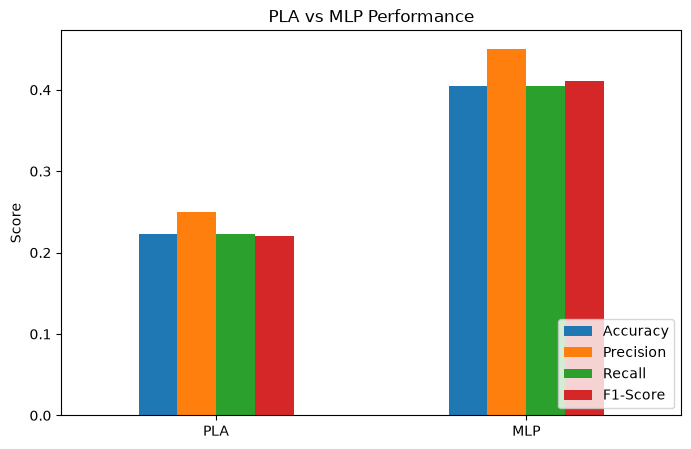

In [7]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")
    return [acc, prec, rec, f1]

metrics_pla = evaluate_model("PLA", y_test, y_pred_pla)
metrics_mlp = evaluate_model("Tuned MLP", y_test, y_pred_mlp)

# Plotting metrics
metrics_df = pd.DataFrame([metrics_pla, metrics_mlp], 
                          columns=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
                          index=['PLA', 'MLP'])
metrics_df.plot(kind='bar', figsize=(8, 5))
plt.title('PLA vs MLP Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
import os; os.makedirs('./images', exist_ok=True)
plt.savefig('./images/exp9_plot_1.pdf', format='pdf', bbox_inches='tight')
plt.show()



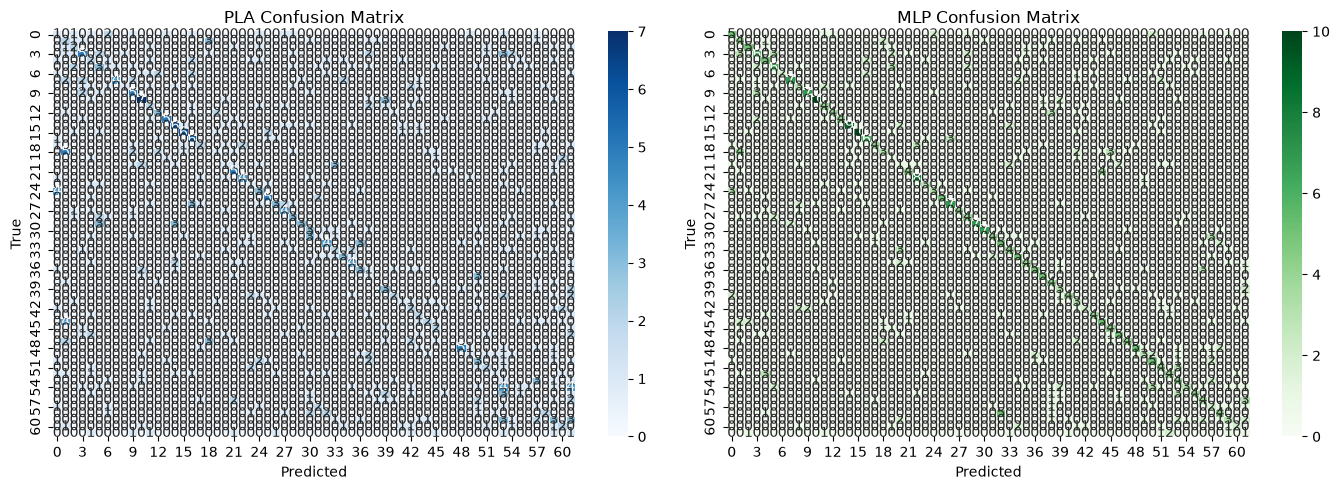

In [8]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_pla), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("PLA Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("MLP Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig('./images/exp9_plot_2.pdf', format='pdf', bbox_inches='tight')
plt.show()



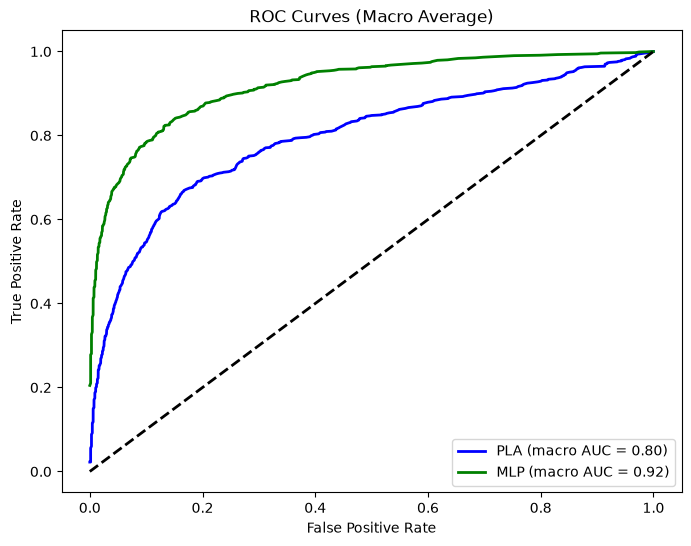

In [9]:
# ROC Curves (Macro average)
# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Predict probabilities (MLP) and Decision Function (PLA)
y_score_mlp = best_mlp.predict_proba(X_test)
y_score_pla = np.dot(X_test, pla.weights.T) + pla.bias

def plot_macro_roc(y_true, y_score, name, color):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    
    macro_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, label=f'{name} (macro AUC = {macro_auc:.2f})', color=color, linewidth=2)

plt.figure(figsize=(8, 6))
plot_macro_roc(y_test_bin, y_score_pla, "PLA", "blue")
plot_macro_roc(y_test_bin, y_score_mlp, "MLP", "green")
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curves (Macro Average)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig('./images/exp9_plot_3.pdf', format='pdf', bbox_inches='tight')
plt.show()



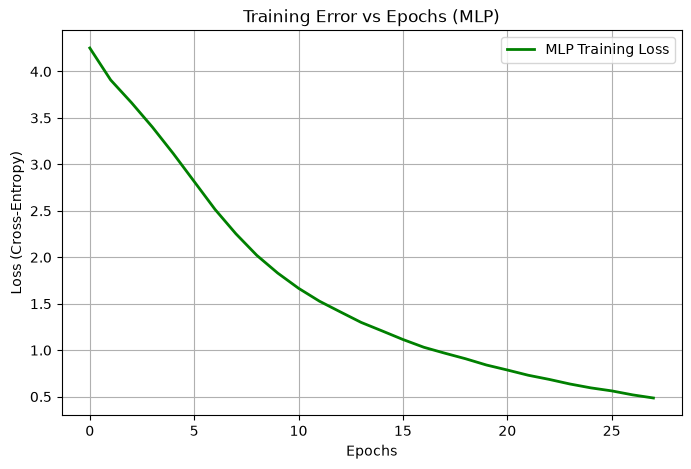

In [10]:
# Training error vs epochs convergence curves (for MLP)
plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_, label='MLP Training Loss', color='green', linewidth=2)
plt.title('Training Error vs Epochs (MLP)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.savefig('./images/exp9_plot_4.pdf', format='pdf', bbox_inches='tight')
plt.show()



## 6. Observations and Analysis
- **PLA vs MLP**: PLA underperforms significantly compared to MLP on complex image datasets because it can only learn linearly separable boundaries.
- **Hyperparameters**: Optimizers (like Adam) generally offer faster convergence. Adding hidden layers allows the MLP to model non-linear boundaries. Overfitting can be observed if validation accuracy drops while training error continues to fall (mitigated by early stopping or regularization).

